In [1]:
import nd2
import matplotlib.pyplot as plt
import hvplot.xarray
import hvplot
import panel as pn
import numpy as np
import xarray as xr
import dask
import dask.array as da
from dask.distributed import Client, LocalCluster
from dask import delayed
from typing import List
from pystackreg import StackReg
from collections import Counter, defaultdict
from typing import Union, List, Any
cluster = LocalCluster(
    processes=True,       
    threads_per_worker=1, 
    n_workers=32,          
    memory_limit='20GB'   
)
client = Client(cluster)
hvplot.extension('bokeh')

client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 32
Total threads: 32,Total memory: 596.05 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33925,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44791,Total threads: 1
Dashboard: http://127.0.0.1:37229/status,Memory: 18.63 GiB
Nanny: tcp://127.0.0.1:45481,


In [2]:
def add_identity_frame_multi_fov(matrices: xr.DataArray, original_ref: xr.DataArray) -> xr.DataArray:
    """
    Prepends identity matrices to the stack, handling (T, P, row, col) or (T, row, col).
    """
    # 1. Identify non-matrix dimensions (e.g., P) excluding T, row, col
    non_matrix_dims = [d for d in matrices.dims if d not in {'T', 'row', 'col'}]
    
    # 2. Create the identity block (1, 3, 3)
    eye_data = np.eye(3)[None, :, :]
    
    # 3. If there are extra dims (like P), we must broadcast the identity matrix
    if non_matrix_dims:
        # Get shape of the extra dimensions from the input matrices
        extra_shape = tuple(matrices.sizes[d] for d in non_matrix_dims)
        # Reshape to (1, P, ..., 3, 3)
        expand_shape = (1,) + extra_shape + (3, 3)
        # Broadcast 
        eye_data = np.broadcast_to(eye_data, expand_shape)

    # 4. Create DataArray
    # Construct coords for the first timepoint
    first_t_coord = original_ref.coords['T'].isel(T=[0])
    
    # Coordinates for P (and others) must match the input matrices
    coords = {d: matrices.coords[d] for d in non_matrix_dims}
    coords['T'] = first_t_coord

    identity_da = xr.DataArray(
        eye_data, 
        dims=['T'] + non_matrix_dims + ['row', 'col'],
        coords=coords
    )
    
    # 5. Concatenate
    full_stack = xr.concat([identity_da, matrices], dim='T')
    full_stack['T'] = original_ref.coords['T']
    
    return full_stack

def get_cumulative_matrices_vectorized(matrices_da: xr.DataArray) -> xr.DataArray:
    """
    Computes cumulative matrix product along T, preserving P dimension.
    """
    # Pull to memory
    mats_np = matrices_da.compute().values
    
    # Initialize output
    cumulative = np.zeros_like(mats_np)
    
    # Determine axis indices for standard matrix multiplication
    # Assumes dims are (T, P, row, col) or (T, row, col)
    # The last two dimensions are always row, col (3, 3)
    
    # Set T=0
    cumulative[0] = mats_np[0]
    
    # Iterate T
    # NumPy @ operator broadcasts over the P dimension automatically
    for t in range(1, len(mats_np)):
        cumulative[t] = cumulative[t-1] @ mats_np[t]
        
    return xr.DataArray(
        cumulative,
        dims=matrices_da.dims,
        coords=matrices_da.coords
    )

def get_lazy_matrix(ref_da: xr.DataArray, mov_da: xr.DataArray) -> xr.DataArray:
    """
    Lazily computes the transformation matrix between two DataArrays.
    """
    return xr.apply_ufunc(
        _register_and_get_matrix,
        ref_da,
        mov_da,
        input_core_dims=[['Y', 'X'], ['Y', 'X']],  # Assuming nd2 uses uppercase Y, X
        output_core_dims=[['row', 'col']],         # The output is a 3x3 matrix
        vectorize=False,                            # Vectorise over non-core dims if present
        dask='allowed',                       # Enable Dask handling
        output_dtypes=[np.float64],
        dask_gufunc_kwargs={'output_sizes': {'row': 3, 'col': 3}},
        keep_attrs=False #drop the nd2 metadata
    )

def _register_and_get_matrix(ref: np.ndarray, mov: np.ndarray) -> np.ndarray:
    """
    Worker function to register two images and extract the transformation matrix.
    
    This function instantiates StackReg locally to ensure thread safety 
    across Dask workers.
    """
    # Ensure inputs are 2D arrays (handle potential extra singleton dims)
    ref_sq = np.squeeze(ref)
    mov_sq = np.squeeze(mov)
    
    assert ref_sq.ndim == 2, "Reference image must be 2D"
    assert mov_sq.ndim == 2, "Moving image must be 2D"
    sr = StackReg(StackReg.RIGID_BODY)
    sr.register(ref_sq, mov_sq)
    return sr.get_matrix()

def plot_drift_diagnostics(mats_abs: xr.DataArray, savedir = None) -> None:
    """
    Plots the spatial registration trace and the temporal drift for X and Y dimensions.

    Args:
        mats_abs (xr.DataArray): An xarray DataArray containing the transformation
                                 matrices. Expected shape involves dimensions for
                                 Time, Rows (2), and Cols (3). Must contain 'P'
                                 (Position) and 'T' (Time in ms) coordinates.
    """
    # Extract data for legibility and performance
    # Column 2, Row 0 is X translation; Column 2, Row 1 is Y translation
    x_drift = mats_abs[:, 0, 2]
    y_drift = mats_abs[:, 1, 2]
    
    # Convert time from milliseconds to hours
    time_hours = mats_abs["T"] / (1000 * 3600)
    
    position_idx: int | str = mats_abs["P"].values.item()

    # Initialize subplots: 1 row, 3 columns
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))

    # --- Panel 1: Spatial Trajectory (X vs Y) ---
    axs[0].plot(x_drift, y_drift, lw=1, alpha=0.8, color='k')
    axs[0].scatter(x_drift[0], y_drift[0], c='green', label='Start', zorder=5)
    axs[0].scatter(x_drift[-1], y_drift[-1], c='red', label='End', zorder=5)
    
    axs[0].set_title(f"Spatial Trace: Pos {position_idx}")
    axs[0].set_xlabel("X Drift (px)")
    axs[0].set_ylabel("Y Drift (px)")
    axs[0].legend()
    axs[0].grid(True, linestyle='--', alpha=0.5)

    # --- Panel 2: X Drift over Time ---
    axs[1].plot(time_hours, x_drift, lw=1.5, color='tab:blue')
    axs[1].set_title("X Drift vs Time")
    axs[1].set_xlabel("Time (h)")
    axs[1].set_ylabel("X Drift (px)")
    axs[1].grid(True, linestyle='--', alpha=0.5)

    # --- Panel 3: Y Drift over Time ---
    axs[2].plot(time_hours, y_drift, lw=1.5, color='tab:orange')
    axs[2].set_title("Y Drift vs Time")
    axs[2].set_xlabel("Time (h)")
    axs[2].set_ylabel("Y Drift (px)")
    axs[2].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    if savedir:
        plt.savefig(savedir)
    plt.show()

def rename_duplicate_coords(
    data: Union[xr.DataArray, xr.Dataset], 
    dim: str
) -> Union[xr.DataArray, xr.Dataset]:
    """
    Identifies duplicate values in a specified xarray dimension and renames them 
    by appending a numerical suffix (e.g., -01, -02).
    
    Values that occur only once are left unchanged. Values that occur multiple 
    times are all renamed to ensure uniqueness and order preservation.

    Parameters
    ----------
    data : Union[xr.DataArray, xr.Dataset]
        The input xarray object containing the dimension to be processed.
    dim : str
        The name of the dimension/coordinate containing duplicates.

    Returns
    -------
    Union[xr.DataArray, xr.Dataset]
        A copy of the input data with unique coordinate labels for the specified dimension.
    """
    
    # Validation to ensure dimension exists
    if dim not in data.coords:
        raise ValueError(f"Dimension '{dim}' not found in coordinates.")

    # Extract original values. We convert to a list to iterate easily.
    # We ensure they are strings to allow for string concatenation.
    original_values: List[Any] = data.coords[dim].values.tolist()
    
    # Count occurrences of each value to identify duplicates
    value_counts: Counter = Counter(original_values)
    
    # Tracker for the current index of the duplicate being processed
    current_counts: defaultdict = defaultdict(int)
    
    new_values: List[str] = []
    
    for val in original_values:
        # Increment the counter for this specific value
        current_counts[val] += 1
        
        # If the value appears more than once in the total dataset, rename it
        if value_counts[val] > 1:
            # Format: OriginalValue-01, OriginalValue-02, etc.
            # The :02d format specifier ensures zero-padding for single digits.
            new_name = f"{val}-{current_counts[val]:02d}"
            new_values.append(new_name)
        else:
            # If unique, preserve the original name
            new_values.append(str(val))
            
    # Assign the new values back to the coordinate
    # We use assign_coords to ensure a new object is returned (immutability)
    return data.assign_coords({dim: new_values})


In [3]:
experiment_nd2 = nd2.imread("/data/20251127_SB1_M9-0.05_24hrsOld_1hrAmpicillin_differentConcs.nd2", dask=True, xarray=True)[:30,::30]
experiment_nd2 = rename_duplicate_coords(experiment_nd2, "P")

In [4]:
experiment_nd2.hvplot.image(x="X", y="Y", cmap="Greys_r", dynamic=True, rasterize=True, framewise=False, widget_location="top", aspect='equal')

BokehModel(combine_events=True, render_bundle={'docs_json': {'3d0739e4-27fa-4cab-88fb-a28641cdb7fc': {'version…

In [5]:
ref_stack = experiment_nd2.isel(T=slice(0, -1))
mov_stack = experiment_nd2.isel(T=slice(1, None))
mov_stack['T'] = ref_stack['T']

In [6]:
relative_matrices_lazy = xr.apply_ufunc(
    _register_and_get_matrix,
    ref_stack,
    mov_stack,
    input_core_dims=[['Y', 'X'], ['Y', 'X']],
    output_core_dims=[['row', 'col']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[np.float64],
    dask_gufunc_kwargs={'output_sizes': {'row': 3, 'col': 3}},
    keep_attrs=False
)

relative_matrices_with_identity = add_identity_frame_multi_fov(
    relative_matrices_lazy, 
    experiment_nd2
)

In [7]:
relative_matrices_with_identity

<xarray.DataArray (T: 30, P: 6, row: 3, col: 3)> Size: 13kB
dask.array<concatenate, shape=(30, 6, 3, 3), dtype=float64, chunksize=(1, 1, 3, 3), chunktype=numpy.ndarray>
Coordinates:
  * T        (T) float64 240B 0.0 1.8e+05 3.6e+05 ... 4.86e+06 5.04e+06 5.22e+06
  * P        (P) <U8 192B 'A01_0000' 'A31_0030' ... 'A37_0036' 'A25_0024'
Dimensions without coordinates: row, col

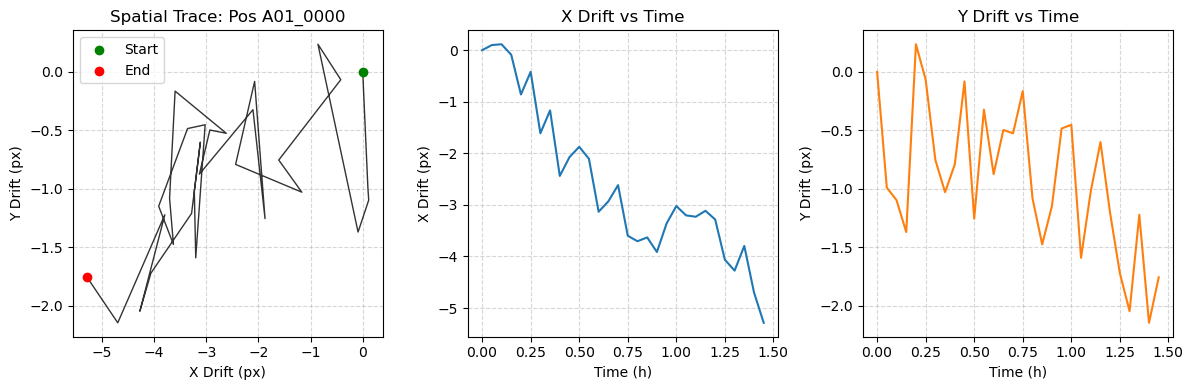

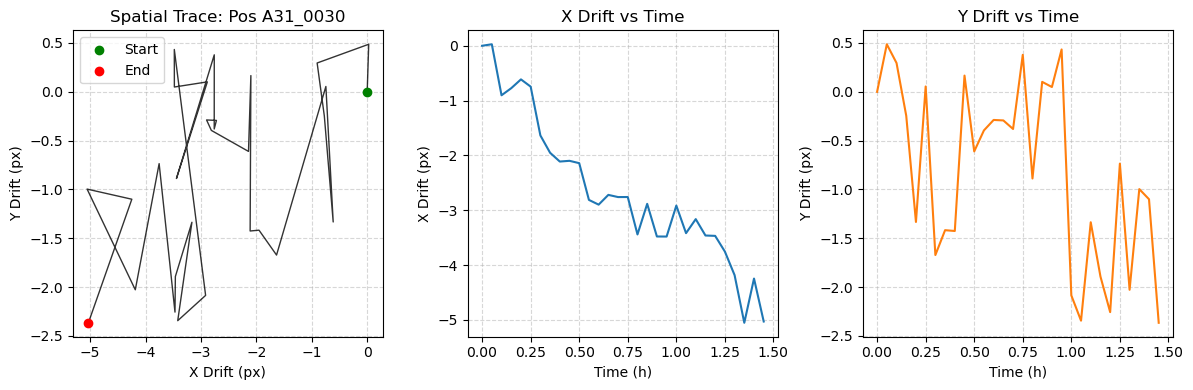

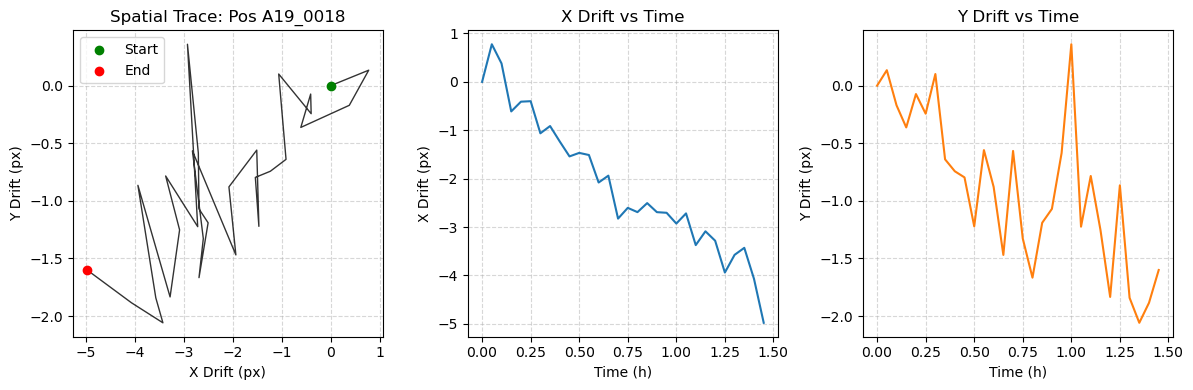

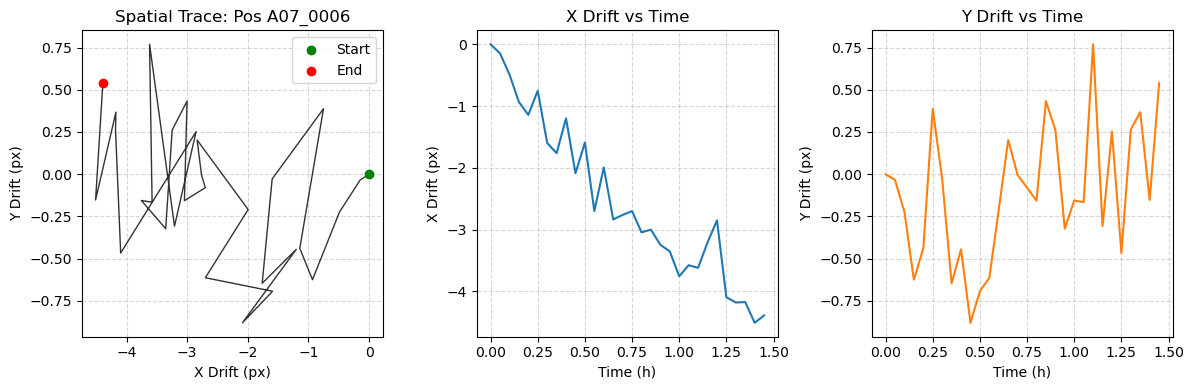

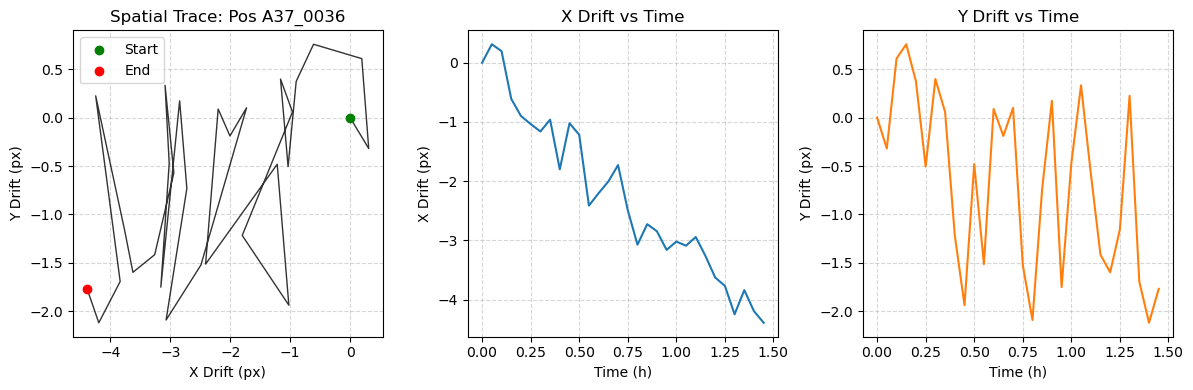

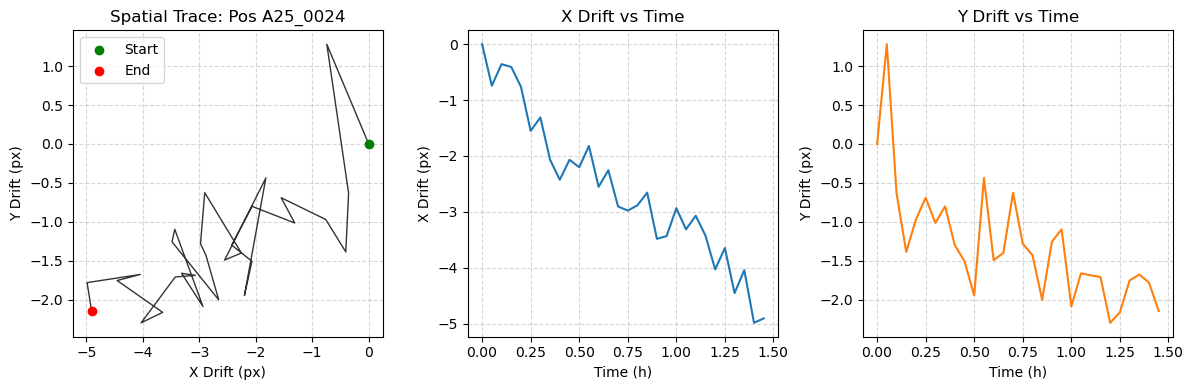

In [8]:
tmats_abs = []
for position in relative_matrices_with_identity["P"].values:
    tmat = relative_matrices_with_identity.sel(P=position.item()).compute()
    mats_abs = get_cumulative_matrices_vectorized(tmat)
    tmats_abs.append(mats_abs)
    plot_drift_diagnostics(mats_abs, savedir=f"diagnostics/drift_{position.item()}.png")
all_tmats_abs = xr.concat(tmats_abs, dim="P")

In [ ]:
# or do it in one compute pass
tmats = relative_matrices_with_identity.compute()
all_tmats_abs = get_cumulative_matrices_vectorized(tmats)

In [21]:
from skimage.transform import warp
def _warp_frame(image: np.ndarray, matrix: np.ndarray) -> np.ndarray:
    """
    Worker function to warp a single 2D image using a 3x3 matrix.
    """
    # dont invert the matrix, pystackreg already does it
    
    return warp(
        image, 
        matrix, 
        preserve_range=True, # Keep original intensity values
        order=1              # Bicubic interpolation (slower but better quality)
    )


In [22]:
stabilized_experiment = xr.apply_ufunc(
    _warp_frame,
    experiment_nd2,
    all_tmats_abs,
    input_core_dims=[['Y', 'X'], ['row', 'col']],
    output_core_dims=[['Y', 'X']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[experiment_nd2.dtype],
    dask_gufunc_kwargs={
        'output_sizes': {
            'Y': experiment_nd2.sizes['Y'], 
            'X': experiment_nd2.sizes['X']
        }
    },
    keep_attrs=True
)

# 5. Output
# stabilized_experiment is now a lazy dask array of the same shape as input
# (T, P, Y, X), but stabilized.
stabilized_experiment

<xarray.DataArray '_dask_block-016e378cc4b7ffe27f270296e3d25ba0' (T: 30, P: 6,
                                                                  Y: 2304,
                                                                  X: 2304)> Size: 2GB
dask.array<transpose, shape=(30, 6, 2304, 2304), dtype=uint16, chunksize=(1, 1, 2304, 2304), chunktype=numpy.ndarray>
Coordinates:
  * T        (T) float64 240B 0.0 1.8e+05 3.6e+05 ... 4.86e+06 5.04e+06 5.22e+06
  * P        (P) <U8 192B 'A01_0000' 'A31_0030' ... 'A37_0036' 'A25_0024'
  * Y        (Y) float64 18kB 0.0 0.1618 0.3236 0.4854 ... 372.3 372.5 372.6
  * X        (X) float64 18kB 0.0 0.1618 0.3236 0.4854 ... 372.3 372.5 372.6
Attributes:
    metadata:  {'metadata': Metadata(contents=Contents(channelCount=1, frameC...

In [23]:
stabilized_experiment.data.dask

HighLevelGraph with 7 layers.
<dask.highlevelgraph.HighLevelGraph object at 0x7069519bce90>
 0. array-7273ace08dbbe7964b82ca9c611735ec
 1. rechunk-merge-433b8563a9fef102ada4bda35df1521e
 2. _dask_block-016e378cc4b7ffe27f270296e3d25ba0
 3. getitem-087aba6782862ad144a351ddfb60a11f
 4. vectorize__warp_frame-e0f490d72a58c81f50d928895371e55d
 5. vectorize__warp_frame_0-e0f490d72a58c81f50d928895371e55d
 6. transpose-79a144bf4e86cb9eb8ce46e294f4ee4d

In [24]:
stabilized_experiment.hvplot.image(x="X", y="Y", cmap="Greys_r", dynamic=True, rasterize=True, framewise=False, widget_location="top", aspect='equal')

BokehModel(combine_events=True, render_bundle={'docs_json': {'6923a13c-b87f-4ac5-b23c-22633a31d253': {'version…

In [31]:
from dask_image.ndfilters import gaussian_filter

In [28]:
mean_x = stabilized_experiment.mean(dim="X")

In [35]:
mean_x.get_axis_num("Y")

2

In [33]:
gaussian_filter(mean_x, sigma=1)

AttributeError: 'DataArray' object has no attribute 'map_overlap'

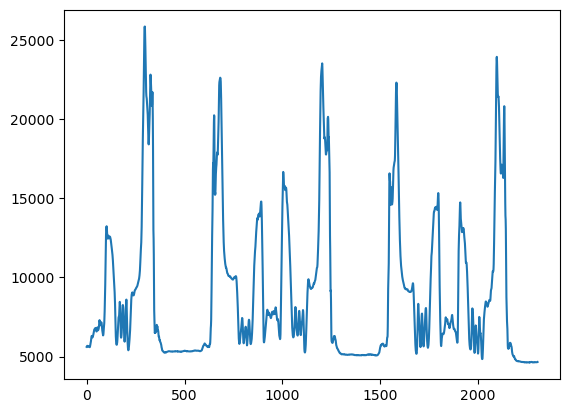

In [30]:
plt.plot(mean_x[0,0])